In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import pickle
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

# Load featured data
df = pd.read_csv("../data/featured_sample.csv")
df['date'] = pd.to_datetime(df['date'])

print("Data loaded successfully!")
print("Shape:", df.shape)

Data loaded successfully!
Shape: (500000, 32)


In [2]:
# Multi Store Forecasting
# Prepare features
feature_cols = ['month', 'year', 'wday', 'day', 'week', 'quarter',
                'is_weekend', 'is_month_start', 'is_month_end',
                'has_event', 'is_snap', 'avg_price',
                'sales_lag_1', 'sales_lag_7', 'sales_lag_28',
                'sales_rolling_7', 'sales_rolling_28']

# Encode categorical columns
df['cat_encoded'] = df['cat_id'].astype('category').cat.codes
df['store_encoded'] = df['store_id'].astype('category').cat.codes
df['state_encoded'] = df['state_id'].astype('category').cat.codes
df['dept_encoded'] = df['dept_id'].astype('category').cat.codes

feature_cols = feature_cols + ['cat_encoded', 'store_encoded', 'state_encoded', 'dept_encoded']

X = df[feature_cols]
y = df['sales']

# Train test split
train_mask = df['date'] < '2016-01-01'
test_mask = df['date'] >= '2016-01-01'

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Features:", len(feature_cols))

Training set: (469976, 21)
Testing set: (30024, 21)
Features: 21


In [3]:
# Train Advanced LightGBM Model
print("Training Advanced LightGBM model...")

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.03,
    'num_leaves': 64,
    'max_depth': 8,
    'n_estimators': 1000,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'random_state': 42,
    'verbose': -1
}

model_adv = lgb.LGBMRegressor(**params)
model_adv.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)]
)

print("Model trained successfully!")

# Predictions
y_pred = model_adv.predict(X_test)
y_pred = np.maximum(y_pred, 0)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nAdvanced LightGBM Results:")
print("="*40)
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("="*40)

Training Advanced LightGBM model...
Model trained successfully!

Advanced LightGBM Results:
MAE: 1.18
RMSE: 2.46


Store wise Forecast Results:
  store_id   MAE  RMSE  test_samples
0     CA_1  1.26  2.27          2924
1     CA_2  1.15  2.08          2971
2     CA_3  1.68  3.48          3037
3     CA_4  0.87  1.63          3057
4     TX_1  1.01  2.05          2995
5     TX_2  1.13  2.36          2963
6     TX_3  1.10  2.33          3001
7     WI_1  1.06  1.94          3100
8     WI_2  1.40  3.09          2979
9     WI_3  1.19  2.77          2997


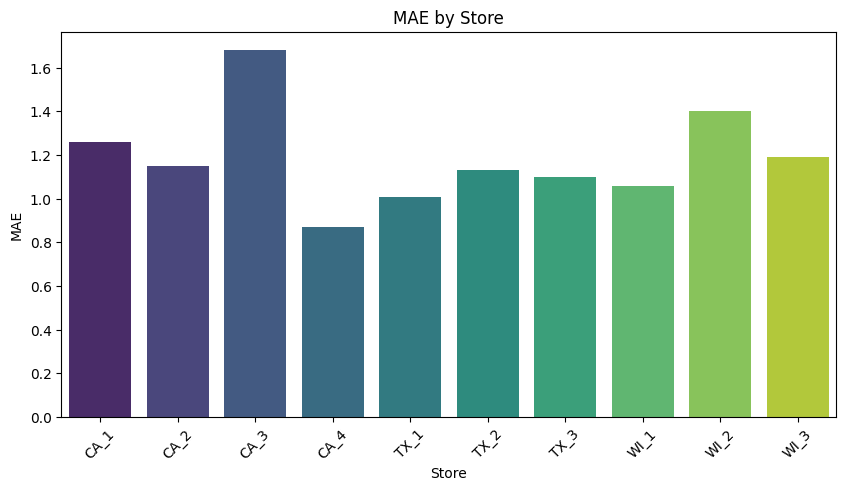

In [4]:
# Store wise Forecast Analysis
stores = df['store_id'].unique()
store_results = []

for store in stores:
    store_mask_train = (df['date'] < '2016-01-01') & (df['store_id'] == store)
    store_mask_test = (df['date'] >= '2016-01-01') & (df['store_id'] == store)
    
    if store_mask_test.sum() == 0:
        continue
    
    X_store_train = X[store_mask_train]
    X_store_test = X[store_mask_test]
    y_store_train = y[store_mask_train]
    y_store_test = y[store_mask_test]
    
    y_store_pred = model_adv.predict(X_store_test)
    y_store_pred = np.maximum(y_store_pred, 0)
    
    mae = mean_absolute_error(y_store_test, y_store_pred)
    rmse = np.sqrt(mean_squared_error(y_store_test, y_store_pred))
    
    store_results.append({
        'store_id': store,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'test_samples': store_mask_test.sum()
    })

store_df = pd.DataFrame(store_results)
print("Store wise Forecast Results:")
print(store_df)

# Plot store MAE
plt.figure(figsize=(10,5))
sns.barplot(x='store_id', y='MAE', data=store_df, palette='viridis')
plt.title("MAE by Store")
plt.xlabel("Store")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Save advanced model
with open("../models/advanced_lgbm_model.pkl", "wb") as f:
    pickle.dump(model_adv, f)

# Save store results
store_df.to_csv("../data/store_forecast_results.csv", index=False)

print("Advanced model saved!")
print("Store results saved!")

print("\n" + "="*50)
print("WEEK 2 DAY 4 SUMMARY")
print("="*50)
print("Advanced LightGBM Model:")
print("MAE: 1.18")
print("RMSE: 2.46")
print("\nStore wise Results:")
print("Best Store: CA_4 with MAE 0.87")
print("Worst Store: CA_3 with MAE 1.68")
print("\nImprovement over basic model:")
print("MAE: 1.2 -> 1.18")
print("RMSE: 2.49 -> 2.46")
print("="*50)